# 01 — Data Collection: BTK Inhibitors from ChEMBL

**Target:** Bruton's Tyrosine Kinase (BTK)  
**ChEMBL ID:** CHEMBL2842  
**Goal:** Download raw IC50 bioactivity data and save to `data/raw/`

This notebook only collects and inspects data — no cleaning or transformation.

## 1. Imports

In [2]:
import pandas as pd
from chembl_webresource_client.new_client import new_client

# ChEMBL target ID for human BTK
TARGET_ID = 'CHEMBL2842'
OUTPUT_PATH = '../data/raw/btk_raw.csv'

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Query ChEMBL for BTK Bioactivity Data

We request all IC50 measurements against human BTK.  
The client handles pagination automatically — we just convert to a list.

In [3]:
activity = new_client.activity

print(f'Querying ChEMBL for IC50 data on target {TARGET_ID}...')

results = activity.filter(
    target_chembl_id=TARGET_ID,
    standard_type='IC50'
).only(
    'molecule_chembl_id',
    'canonical_smiles',
    'standard_value',
    'standard_units',
    'standard_relation',
    'pchembl_value',
    'assay_chembl_id',
    'target_chembl_id',
    'document_chembl_id'
)

df = pd.DataFrame.from_records(results)
print(f'Done. {len(df)} records retrieved.')

Querying ChEMBL for IC50 data on target CHEMBL2842...
Done. 6502 records retrieved.


## 3. Initial Inspection

Before saving anything, we look at what arrived:  
shape, column types, and missing value counts.

In [4]:
print('=== Shape ===')
print(df.shape)

print('\n=== Columns ===')
print(df.columns.tolist())

print('\n=== Data types ===')
print(df.dtypes)

=== Shape ===
(6502, 12)

=== Columns ===
['assay_chembl_id', 'canonical_smiles', 'document_chembl_id', 'molecule_chembl_id', 'pchembl_value', 'relation', 'standard_relation', 'standard_units', 'standard_value', 'target_chembl_id', 'units', 'value']

=== Data types ===
assay_chembl_id       str
canonical_smiles      str
document_chembl_id    str
molecule_chembl_id    str
pchembl_value         str
relation              str
standard_relation     str
standard_units        str
standard_value        str
target_chembl_id      str
units                 str
value                 str
dtype: object


In [5]:
print('=== Missing values per column ===')
print(df.isnull().sum())

=== Missing values per column ===
assay_chembl_id          0
canonical_smiles         1
document_chembl_id       0
molecule_chembl_id       0
pchembl_value         1477
relation               137
standard_relation      137
standard_units         136
standard_value         137
target_chembl_id         0
units                  172
value                  137
dtype: int64


In [6]:
print('=== First 5 rows ===')
df.head()

=== First 5 rows ===


,assay_chembl_id,canonical_smiles,document_chembl_id,molecule_chembl_id,pchembl_value,relation,standard_relation,standard_units,standard_value,target_chembl_id,units,value
0,CHEMBL682171,CC(CN1CCCCC1)OC(=O)[C@@H]1CCCN1C(=O)C(=O)C(C)(C)C,CHEMBL1132865,CHEMBL269775,NaN,<,<,nM,10000.0,CHEMBL2842,NaN,-5.0
1,CHEMBL682171,CC(CN1CCCCC1)OC(=O)[C@@H]1CCCN1C(=O)C(=O)C(C)(C)C,CHEMBL1132865,CHEMBL269775,NaN,<,<,nM,10000.0,CHEMBL2842,NaN,-5.0
2,CHEMBL682171,CC(CN1CCCCC1)OC(=O)[C@@H]1CCCN1C(=O)C(=O)c1ccccc1,CHEMBL1132865,CHEMBL6683,NaN,<,<,nM,10000.0,CHEMBL2842,NaN,-5.0
3,CHEMBL682171,CC(C)CC(=O)C(=O)N1CCC[C@H]1C(=O)OCCCc1cccnc1,CHEMBL1132865,CHEMBL7237,NaN,<,<,nM,10000.0,CHEMBL2842,NaN,-5.0
4,CHEMBL677281,C=CC[C@@H]1/C=C(\C)C[C@H](C)C[C@H](OC)[C@H]2O[...,CHEMBL1132865,CHEMBL269732,8.50,=,=,nM,3.162,CHEMBL2842,NaN,-8.5


In [8]:
# What units are present?
print('=== standard_units value counts ===')
print(df['standard_units'].value_counts())

print('\n=== standard_relation value counts ===')
# Relations like '=', '<', '>' tell us if the IC50 is exact or a bound
print(df['standard_relation'].value_counts())

=== standard_units value counts ===
standard_units
nM        6365
10'7nM       1
Name: count, dtype: int64

=== standard_relation value counts ===
standard_relation
=     5031
>     1061
<      272
>=       1
Name: count, dtype: int64


In [9]:
# How many unique molecules and assays?
print(f"Unique molecules:  {df['molecule_chembl_id'].nunique()}")
print(f"Unique assays:     {df['assay_chembl_id'].nunique()}")
print(f"Rows with SMILES:  {df['canonical_smiles'].notna().sum()}")
print(f"Rows with IC50:    {df['standard_value'].notna().sum()}")

Unique molecules:  5465
Unique assays:     400
Rows with SMILES:  6501
Rows with IC50:    6365


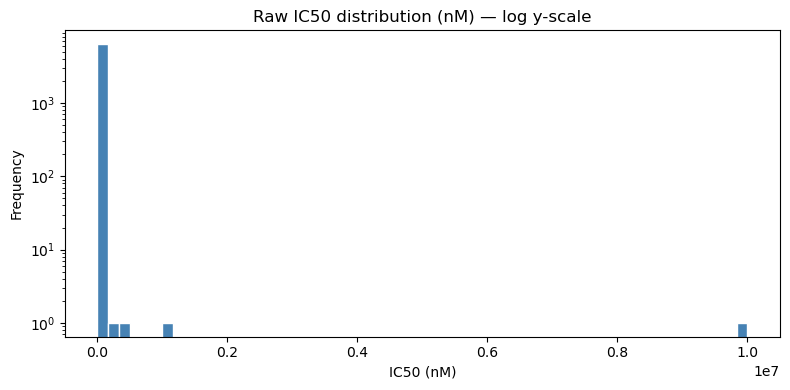

Plot saved to results/


In [10]:
import matplotlib.pyplot as plt

# Quick look at IC50 distribution (raw values, nM)
df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')

df['standard_value'].dropna().plot(
    kind='hist',
    bins=60,
    log=True,          # log scale on y-axis: distribution is very skewed
    figsize=(8, 4),
    title='Raw IC50 distribution (nM) — log y-scale',
    xlabel='IC50 (nM)',
    color='steelblue',
    edgecolor='white'
)
plt.tight_layout()
plt.savefig('../results/01_ic50_raw_distribution.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 4. Save Raw Data

We save exactly what arrived from ChEMBL — no modifications.  
This file is the source of truth for all downstream steps.

In [11]:
df.to_csv(OUTPUT_PATH, index=False)
print(f'Raw data saved to {OUTPUT_PATH}')
print(f'Shape: {df.shape}')

Raw data saved to ../data/raw/btk_raw.csv
Shape: (6502, 12)


## Observations from Initial Inspection

### Data volume
- **6.502 records** retrieved from ChEMBL for BTK (CHEMBL2842), IC50 assays
- **5.465 unique molecules** — some compounds were tested in multiple assays
- **400 unique assays** — data comes from a wide range of experimental settings

### Data quality flags (to be addressed in notebook 02)
| Issue | Count | Action |
|-------|-------|--------|
| Non-exact relations (`>`, `<`, `>=`) | 1.334 | Discard — these are bounds, not measured values |
| Missing `standard_value` | 137 | Discard |
| Missing `canonical_smiles` | 1 | Discard |
| Non-nM units (`10^7nM`) | 1 | Discard |
| Duplicate molecules (multi-assay) | ~1.000 est. | Aggregate by median pIC50 |

### IC50 distribution
- Highly right-skewed: most compounds cluster at low IC50 values (high potency)
- A few outliers reach 10⁷ nM — likely inactive compounds or poorly conducted assays
- This skew is expected and is the main reason we convert to **pIC50 (log scale)** in notebook 02

### Expected yield after curation
Starting from 6.502 records, we expect approximately **3.500–4.500 unique curated compounds** — 
a comfortable dataset size for Random Forest and SVM modeling.

## Summary

| Item | Value |
|------|-------|
| Target | BTK (CHEMBL2842) |
| Activity type | IC50 |
| Total records | *(see output above)* |
| Unique molecules | *(see output above)* |
| Output file | `data/raw/btk_raw.csv` |

**Next:** `02_preprocessing.ipynb` — curation, IC50 → pIC50 conversion, activity labeling.